In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
RUTA = '/content/drive/MyDrive/ia/DelayedFlights.csv'

chunks = []
for chunk in pd.read_csv(RUTA, chunksize=100_000):
    muestra_chunk = chunk.sample(frac=0.10, random_state=42)
    chunks.append(muestra_chunk)

df = pd.concat(chunks, ignore_index=True)
print(f'Muestra cargada: {len(df):,} filas  |  {df.shape[1]} columnas')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Muestra cargada: 193,676 filas  |  30 columnas


In [ ]:
df = df.dropna(subset=['ArrDelay'])

DESCARTAR = ['Year', 'UniqueCarrier', 'FlightNum', 'TailNum',
             'Origin', 'Dest', 'Cancelled', 'CancellationCode', 'Diverted']
DESCARTAR_EXISTENTES = [c for c in DESCARTAR if c in df.columns]
df = df.drop(columns=DESCARTAR_EXISTENTES)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

print(f'Dataset limpio: {len(df):,} filas  |  {df.shape[1]} columnas')

Dataset limpio: 192,898 filas  |  20 columnas


In [ ]:
DELAY_COLS = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
for col in DELAY_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df = df.fillna(df.median(numeric_only=True))

df['TaxiTotal']   = df['TaxiIn'] + df['TaxiOut']
df['ElapsedDiff'] = df['ActualElapsedTime'] - df['CRSElapsedTime']

FEATURES = [
    'Month', 'DayofMonth', 'DayOfWeek',
    'CRSDepTime', 'DepTime', 'CRSArrTime',
    'TaxiIn', 'TaxiOut',
    'CRSElapsedTime', 'AirTime',
    'Distance',
    'TaxiTotal'
]
FEATURES = [f for f in FEATURES if f in df.columns]

X_raw = df[FEATURES].values.astype(float)
y_raw = df['ArrDelay'].values.astype(float)

m, n = X_raw.shape
print(f'Ejemplos (m): {m:,}')
print(f'Características (n): {n}')

Ejemplos (m): 192,898
Características (n): 12


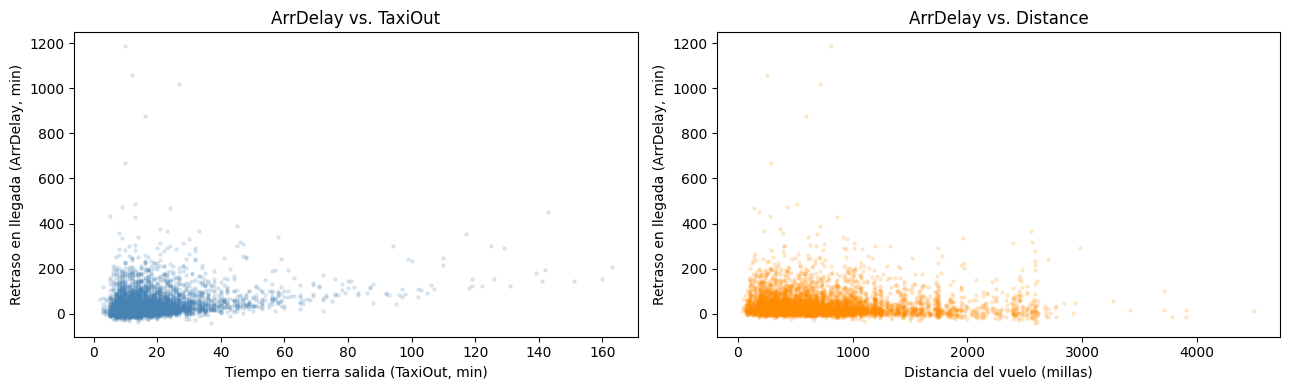

Retraso promedio en llegada: 42.1 min
% vuelos con retraso (>0 min): 89.5%


In [ ]:
idx_plot = np.random.choice(len(y_raw), size=5000, replace=False)

fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X_raw[idx_plot, FEATURES.index('TaxiOut')],
                y_raw[idx_plot], alpha=0.15, s=5, color='steelblue')
axes[0].set_xlabel('Tiempo en tierra salida (TaxiOut, min)')
axes[0].set_ylabel('Retraso en llegada (ArrDelay, min)')
axes[0].set_title('ArrDelay vs. TaxiOut')

axes[1].scatter(X_raw[idx_plot, FEATURES.index('Distance')],
                y_raw[idx_plot], alpha=0.15, s=5, color='darkorange')
axes[1].set_xlabel('Distancia del vuelo (millas)')
axes[1].set_ylabel('Retraso en llegada (ArrDelay, min)')
axes[1].set_title('ArrDelay vs. Distance')

pyplot.tight_layout()
pyplot.show()

print(f'Retraso promedio en llegada: {y_raw.mean():.1f} min')
print(f'% vuelos con retraso (>0 min): {(y_raw > 0).mean()*100:.1f}%')

In [ ]:
np.random.seed(42)
indices   = np.random.permutation(m)
split     = int(0.8 * m)
train_idx = indices[:split]
val_idx   = indices[split:]

X_train_raw = X_raw[train_idx].astype(np.float32)
X_val_raw   = X_raw[val_idx].astype(np.float32)
y_train     = y_raw[train_idx].astype(np.float32)
y_val       = y_raw[val_idx].astype(np.float32)

# normalización manual, igual que en los cuadernillos del inge
mu    = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma[sigma == 0] = 1

X_train_norm = (X_train_raw - mu) / sigma
X_val_norm   = (X_val_raw   - mu) / sigma

print(f'Entrenamiento: {len(y_train):,} ejemplos')
print(f'Validación:    {len(y_val):,} ejemplos')

Entrenamiento: 154,318 ejemplos
Validación:    38,580 ejemplos


In [ ]:
class FlightDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

train_dataset = FlightDataset(X_train_norm, y_train)
val_dataset   = FlightDataset(X_val_norm,   y_val)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)

In [ ]:
def metricas(y_real, y_pred, nombre=''):
    mae  = np.mean(np.abs(y_pred - y_real))
    rmse = np.sqrt(np.mean((y_pred - y_real)**2))
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - y_real.mean())**2)
    r2   = 1 - ss_res / ss_tot
    print(f'══ {nombre} ══')
    print(f'  MAE  (error absoluto medio):  {mae:>8.2f} min')
    print(f'  RMSE (raíz error cuadrático): {rmse:>8.2f} min')
    print(f'  R²   (coef. determinación):   {r2:>8.4f}')
    return mae, rmse, r2

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class RegresionLineal(nn.Module):
    def __init__(self, input_size):
        super(RegresionLineal, self).__init__()
        self.fc = nn.Linear(input_size, 1)
    def forward(self, x):
        return self.fc(x)

model1 = RegresionLineal(X_train_norm.shape[1]).to(device)

In [ ]:
criterion  = nn.MSELoss()
optimizer1 = torch.optim.SGD(model1.parameters(), lr=0.1)

epochs     = 100
J_history1 = []
PATH1      = "./checkpoint_m1.pt"
best_val1  = float('inf')

model1.train()
for epoch in range(1, epochs + 1):
    losses = []
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer1.zero_grad()
        loss = criterion(model1(x_b), y_b)
        loss.backward()
        optimizer1.step()
        losses.append(loss.item())
    J_history1.append(np.mean(losses))

    model1.eval()
    with torch.no_grad():
        val_losses = [criterion(model1(x_b.to(device)), y_b.to(device)).item()
                      for x_b, y_b in val_loader]
    val_loss = np.mean(val_losses)
    if val_loss < best_val1:
        best_val1 = val_loss
        torch.save(model1.state_dict(), PATH1)
    model1.train()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}  loss: {J_history1[-1]:.4f}  val_loss: {val_loss:.4f}")

model1.load_state_dict(torch.load(PATH1))
print(f"\nMejor val_loss M1: {best_val1:.4f}")

Epoch 10/100  loss: 2659.6483  val_loss: 2769.0995
Epoch 20/100  loss: 2662.0542  val_loss: 2753.7632
Epoch 30/100  loss: 2662.0808  val_loss: 2745.5337
Epoch 40/100  loss: 2660.0180  val_loss: 2767.0291
Epoch 50/100  loss: 2660.9308  val_loss: 2747.4209
Epoch 60/100  loss: 2663.1061  val_loss: 2749.0788
Epoch 70/100  loss: 2658.6837  val_loss: 2750.1945
Epoch 80/100  loss: 2659.4439  val_loss: 2759.3284
Epoch 90/100  loss: 2661.7008  val_loss: 2766.5219
Epoch 100/100  loss: 2660.7276  val_loss: 2762.8228

Mejor val_loss M1: 2745.1242


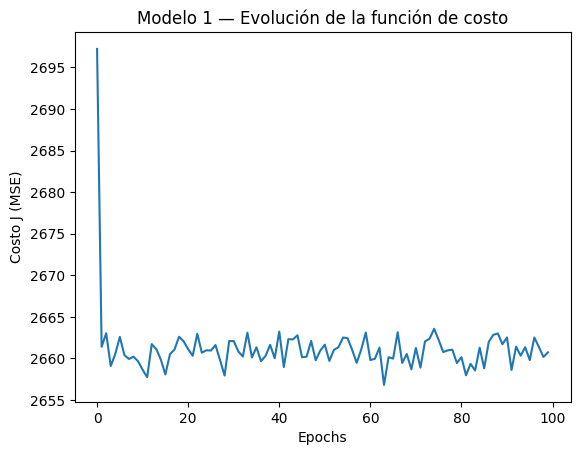

In [ ]:
pyplot.plot(J_history1)
pyplot.title('Modelo 1 — Evolución de la función de costo')
pyplot.xlabel('Epochs')
pyplot.ylabel('Costo J (MSE)')
pyplot.show()

--- Entrenamiento ---
══ M1 Train ══
  MAE  (error absoluto medio):     32.08 min
  RMSE (raíz error cuadrático):    51.40 min
  R²   (coef. determinación):     0.1626

--- Validación ---
══ M1 Validación ══
  MAE  (error absoluto medio):     32.18 min
  RMSE (raíz error cuadrático):    52.41 min
  R²   (coef. determinación):     0.1552


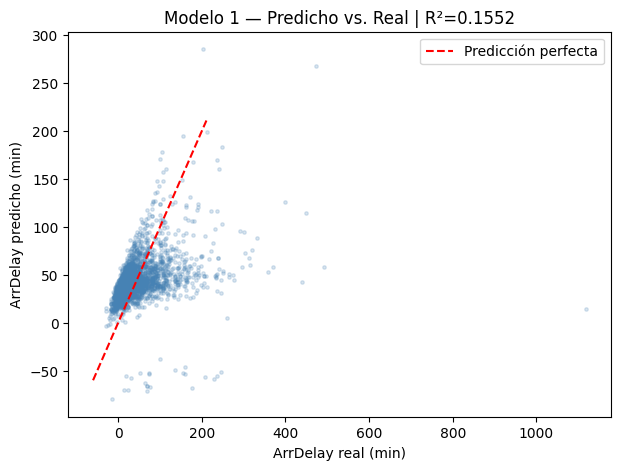

In [ ]:
model1.eval()
with torch.no_grad():
    y_pred1_train = model1(torch.from_numpy(X_train_norm).to(device)).cpu().numpy().flatten()
    y_pred1_val   = model1(torch.from_numpy(X_val_norm).to(device)).cpu().numpy().flatten()

print('--- Entrenamiento ---')
mae1_tr, rmse1_tr, r2_1_tr = metricas(y_train, y_pred1_train, 'M1 Train')
print()
print('--- Validación ---')
mae1_vl, rmse1_vl, r2_1_vl = metricas(y_val, y_pred1_val, 'M1 Validación')

idx_v = np.random.choice(len(y_val), 3000, replace=False)
lim = np.percentile(np.concatenate([y_val, y_pred1_val]), 99)
pyplot.figure(figsize=(7, 5))
pyplot.scatter(y_val[idx_v], y_pred1_val[idx_v], alpha=0.2, s=6, color='steelblue')
pyplot.plot([-60, lim], [-60, lim], 'r--', lw=1.5, label='Predicción perfecta')
pyplot.xlabel('ArrDelay real (min)')
pyplot.ylabel('ArrDelay predicho (min)')
pyplot.title(f'Modelo 1 — Predicho vs. Real | R²={r2_1_vl:.4f}')
pyplot.legend()
pyplot.show()

In [ ]:
def crearFeaturesPol(X_train, X_val, indices_cuad):
    cols_train = [X_train]
    cols_val   = [X_val]
    for idx in indices_cuad:
        col_train = (X_train[:, idx] ** 2).reshape(-1, 1)
        col_val   = (X_val[:, idx] ** 2).reshape(-1, 1)
        # normalizar con media/std del train
        mean = col_train.mean()
        std  = col_train.std() + 1e-8
        cols_train.append((col_train - mean) / std)
        cols_val.append((col_val   - mean) / std)
    return np.hstack(cols_train), np.hstack(cols_val)

IDX_CUAD = []
for nombre in ['DepDelay', 'CarrierDelay', 'WeatherDelay', 'LateAircraftDelay']:
    if nombre in FEATURES:
        IDX_CUAD.append(FEATURES.index(nombre))

X_train_pol, X_val_pol = crearFeaturesPol(X_train_norm, X_val_norm, IDX_CUAD)
print(f'Dimensión X_train polinómica: {X_train_pol.shape}')

Dimensión X_train polinómica: (154318, 12)


In [ ]:
train_dataset2 = FlightDataset(X_train_pol, y_train)
val_dataset2   = FlightDataset(X_val_pol,   y_val)
train_loader2  = DataLoader(train_dataset2, batch_size=256, shuffle=True)
val_loader2    = DataLoader(val_dataset2,   batch_size=256, shuffle=False)

model2     = RegresionLineal(X_train_pol.shape[1]).to(device)
optimizer2 = torch.optim.SGD(model2.parameters(), lr=0.1)

J_history2 = []
PATH2      = "./checkpoint_m2.pt"
best_val2  = float('inf')

model2.train()
for epoch in range(1, epochs + 1):
    losses = []
    for x_b, y_b in train_loader2:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer2.zero_grad()
        loss = criterion(model2(x_b), y_b)
        loss.backward()
        optimizer2.step()
        losses.append(loss.item())
    J_history2.append(np.mean(losses))

    model2.eval()
    with torch.no_grad():
        val_losses = [criterion(model2(x_b.to(device)), y_b.to(device)).item()
                      for x_b, y_b in val_loader2]
    val_loss = np.mean(val_losses)
    if val_loss < best_val2:
        best_val2 = val_loss
        torch.save(model2.state_dict(), PATH2)
    model2.train()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}  loss: {J_history2[-1]:.4f}  val_loss: {val_loss:.4f}")

model2.load_state_dict(torch.load(PATH2))
print(f"\nMejor val_loss M2: {best_val2:.4f}")

Epoch 10/100  loss: 2663.3551  val_loss: 2845.5462
Epoch 20/100  loss: 2663.7839  val_loss: 2757.7064
Epoch 30/100  loss: 2660.5367  val_loss: 2759.4372
Epoch 40/100  loss: 2660.0398  val_loss: 2775.9693
Epoch 50/100  loss: 2662.8920  val_loss: 2753.3773
Epoch 60/100  loss: 2660.6518  val_loss: 2772.2694
Epoch 70/100  loss: 2661.3333  val_loss: 2757.9093
Epoch 80/100  loss: 2660.7793  val_loss: 2762.8680
Epoch 90/100  loss: 2660.9935  val_loss: 2747.4714
Epoch 100/100  loss: 2658.8286  val_loss: 2809.7683

Mejor val_loss M2: 2743.2184


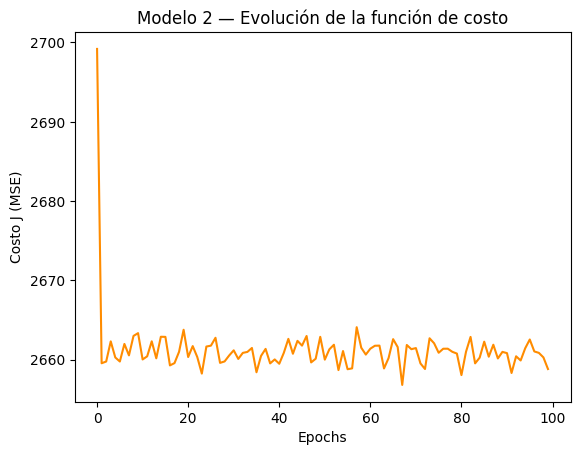

In [ ]:
pyplot.plot(J_history2, color='darkorange')
pyplot.title('Modelo 2 — Evolución de la función de costo')
pyplot.xlabel('Epochs')
pyplot.ylabel('Costo J (MSE)')
pyplot.show()

--- Entrenamiento ---
══ M2 Train ══
  MAE  (error absoluto medio):     31.92 min
  RMSE (raíz error cuadrático):    51.39 min
  R²   (coef. determinación):     0.1632

--- Validación ---
══ M2 Validación ══
  MAE  (error absoluto medio):     32.01 min
  RMSE (raíz error cuadrático):    52.40 min
  R²   (coef. determinación):     0.1558


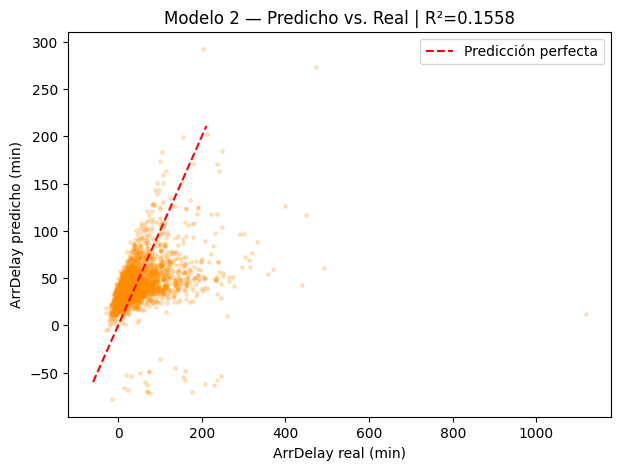

In [ ]:
model2.eval()
with torch.no_grad():
    y_pred2_train = model2(torch.from_numpy(X_train_pol).to(device)).cpu().numpy().flatten()
    y_pred2_val   = model2(torch.from_numpy(X_val_pol).to(device)).cpu().numpy().flatten()

print('--- Entrenamiento ---')
mae2_tr, rmse2_tr, r2_2_tr = metricas(y_train, y_pred2_train, 'M2 Train')
print()
print('--- Validación ---')
mae2_vl, rmse2_vl, r2_2_vl = metricas(y_val, y_pred2_val, 'M2 Validación')

pyplot.figure(figsize=(7, 5))
pyplot.scatter(y_val[idx_v], y_pred2_val[idx_v], alpha=0.2, s=6, color='darkorange')
pyplot.plot([-60, lim], [-60, lim], 'r--', lw=1.5, label='Predicción perfecta')
pyplot.xlabel('ArrDelay real (min)')
pyplot.ylabel('ArrDelay predicho (min)')
pyplot.title(f'Modelo 2 — Predicho vs. Real | R²={r2_2_vl:.4f}')
pyplot.legend()
pyplot.show()

In [ ]:
# Modelo 3 se mantiene en numpy porque la ecuación normal es una
# solución analítica de un solo paso, no hay entrenamiento iterativo.
def ecuacionNormal(X, y):
    return np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)

def agregarColumnaUnos(X):
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

X_tr3 = agregarColumnaUnos(X_train_raw)
X_vl3 = agregarColumnaUnos(X_val_raw)

theta3 = ecuacionNormal(X_tr3, y_train)
print('Ecuación Normal calculada ✔')

Ecuación Normal calculada ✔


--- Entrenamiento ---
══ M3 Train ══
  MAE  (error absoluto medio):     32.02 min
  RMSE (raíz error cuadrático):    51.37 min
  R²   (coef. determinación):     0.1639

--- Validación ---
══ M3 Validación ══
  MAE  (error absoluto medio):     32.12 min
  RMSE (raíz error cuadrático):    52.38 min
  R²   (coef. determinación):     0.1563


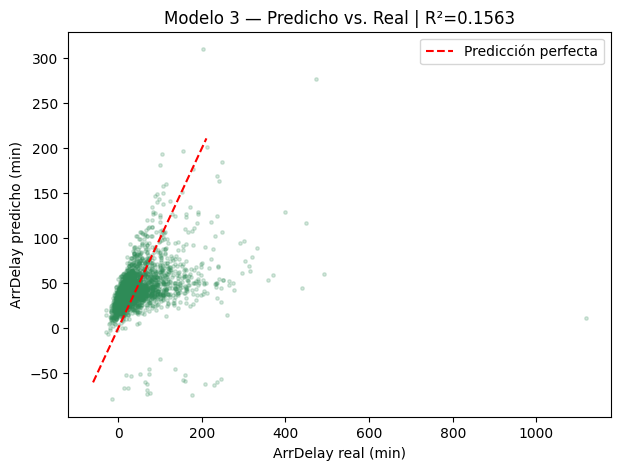

In [ ]:
y_pred3_train = X_tr3.dot(theta3)
y_pred3_val   = X_vl3.dot(theta3)

print('--- Entrenamiento ---')
mae3_tr, rmse3_tr, r2_3_tr = metricas(y_train, y_pred3_train, 'M3 Train')
print()
print('--- Validación ---')
mae3_vl, rmse3_vl, r2_3_vl = metricas(y_val, y_pred3_val, 'M3 Validación')

pyplot.figure(figsize=(7, 5))
pyplot.scatter(y_val[idx_v], y_pred3_val[idx_v], alpha=0.2, s=6, color='seagreen')
pyplot.plot([-60, lim], [-60, lim], 'r--', lw=1.5, label='Predicción perfecta')
pyplot.xlabel('ArrDelay real (min)')
pyplot.ylabel('ArrDelay predicho (min)')
pyplot.title(f'Modelo 3 — Predicho vs. Real | R²={r2_3_vl:.4f}')
pyplot.legend()
pyplot.show()

In [ ]:
nombres   = ['M1 Lineal', 'M2 Polinómica', 'M3 Ec. Normal']
r2_vals   = [r2_1_vl, r2_2_vl, r2_3_vl]
rmse_vals = [rmse1_vl, rmse2_vl, rmse3_vl]
mae_vals  = [mae1_vl,  mae2_vl,  mae3_vl]

print(f'{"Modelo":<20} {"MAE":>10} {"RMSE":>10} {"R²":>10}')
print('-' * 54)
for nm, mae_v, rmse_v, r2_v in zip(nombres, mae_vals, rmse_vals, r2_vals):
    print(f'{nm:<20} {mae_v:>10.2f} {rmse_v:>10.2f} {r2_v:>10.4f}')

mejor_idx    = int(np.argmax(r2_vals))
nombre_mejor = nombres[mejor_idx]
print(f'\nMejor modelo: {nombre_mejor}  (R²={r2_vals[mejor_idx]:.4f})')

muestra_100 = np.random.choice(len(y_val), size=100, replace=False)

Modelo                      MAE       RMSE         R²
------------------------------------------------------
M1 Lineal                 32.18      52.41     0.1552
M2 Polinómica             32.01      52.40     0.1558
M3 Ec. Normal             32.12      52.38     0.1563

Mejor modelo: M3 Ec. Normal  (R²=0.1563)


In [ ]:
if mejor_idx == 0:
    model1.eval()
    with torch.no_grad():
        y_100_pred = model1(torch.from_numpy(X_val_norm[muestra_100]).to(device)).cpu().numpy().flatten()
elif mejor_idx == 1:
    model2.eval()
    with torch.no_grad():
        y_100_pred = model2(torch.from_numpy(X_val_pol[muestra_100]).to(device)).cpu().numpy().flatten()
else:
    y_100_pred = X_vl3[muestra_100].dot(theta3)

#        ArrDelay Real (min)   ArrDelay Predicho (min)    Error abs
--------------------------------------------------------------------
1                       38.0                      41.9          3.9
2                      148.0                      89.9         58.1
3                      441.0                      63.3        377.7
4                       41.0                      70.0         29.0
5                      175.0                      61.0        114.0
6                       22.0                      35.9         13.9
7                       -6.0                      25.8         31.8
8                        6.0                      35.7         29.7
9                       19.0                      35.5         16.5
10                       1.0                      21.9         20.9
11                       7.0                      40.1         33.1
12                      31.0                      37.6          6.6
13                      -1.0                   

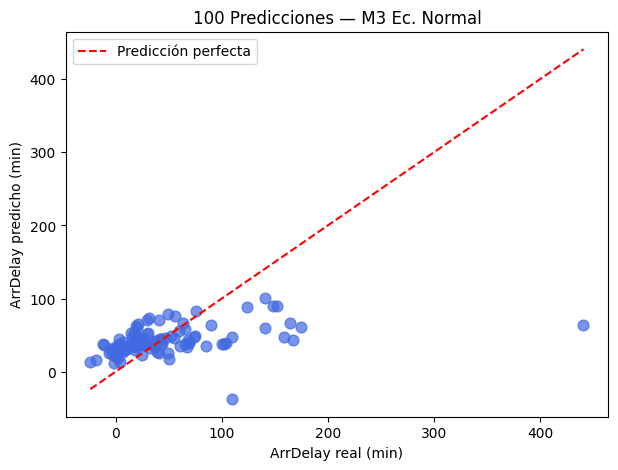


Resumen de las 100 predicciones:
  Error absoluto medio:         33.9 min
  Predicciones con error <5min: 11 / 100
  Predicciones con error <10min:20 / 100


In [ ]:
y_100_real = y_val[muestra_100]
errores_100 = np.abs(y_100_pred - y_100_real)

print(f'{"#":<5} {"ArrDelay Real (min)":>22} {"ArrDelay Predicho (min)":>25} {"Error abs":>12}')
print('-' * 68)
for i, (real, pred) in enumerate(zip(y_100_real, y_100_pred)):
    print(f'{i+1:<5} {real:>22.1f} {pred:>25.1f} {abs(pred-real):>12.1f}')

pyplot.figure(figsize=(7, 5))
pyplot.scatter(y_100_real, y_100_pred, s=60, alpha=0.7, color='royalblue')
pyplot.plot([y_100_real.min(), y_100_real.max()],
            [y_100_real.min(), y_100_real.max()], 'r--', lw=1.5, label='Predicción perfecta')
pyplot.xlabel('ArrDelay real (min)')
pyplot.ylabel('ArrDelay predicho (min)')
pyplot.title(f'100 Predicciones — {nombre_mejor}')
pyplot.legend()
pyplot.show()

print(f'\nResumen de las 100 predicciones:')
print(f'  Error absoluto medio:         {errores_100.mean():.1f} min')
print(f'  Predicciones con error <5min: {(errores_100 < 5).sum()} / 100')
print(f'  Predicciones con error <10min:{(errores_100 < 10).sum()} / 100')